# 03 - Data Preparation: Sampling & Statistical Checks
---
This notebook is used to determine how large should be the size of the sampling that will be used in the modeling phase of the KDD process.

It is also used to check and statistically compare the sampled dataset with the original ones, in order to ensure that both size and representation are preserved.

## Import libraries and settings

In [1]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from fraud_dynamic_ensemble.config import EXTERNAL_DATA_DIR, EXTERNAL_FILENAME, RAW_DATA_DIR, RAW_FILENAME, FIGURES_DIR
from fraud_dynamic_ensemble.evaluation.statistical_test_evaluation import ks_two_sample

2025-11-11 23:20:02.641 | INFO     | fraud_dynamic_ensemble.config:<module>:12 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
original_path : Path = EXTERNAL_DATA_DIR / EXTERNAL_FILENAME
sampled_path : Path = RAW_DATA_DIR / RAW_FILENAME
print(f"Loading ORIGINAL dataset at path:\n\t{original_path}")
print(f"Loading SAMPLED dataset at path:\n\t{sampled_path}")

Loading ORIGINAL dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/data/external/creditcardfraud.csv
Loading SAMPLED dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/data/raw/credit_card_fraud_sampling.csv


In [3]:
FIGURES_SAMPLING_CHECKS_DIR = FIGURES_DIR / "DP_sampling_checks"
FIGURES_SAMPLING_CHECKS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 16})

In [5]:
df_before = pd.read_csv(original_path, header=0, sep=",")
print(f"ORIGINAL Dataset dimension\n"
      f"\t-Number of rows = {df_before.shape[0]}\n"
      f"\t-Number of cols = {df_before.shape[1]}")

ORIGINAL Dataset dimension
	-Number of rows = 284807
	-Number of cols = 31


In [6]:
df_after = pd.read_csv(sampled_path, header=0, sep=",")
print(f"SAMPLED Dataset dimension\n"
      f"\t-Number of rows = {df_after.shape[0]}\n"
      f"\t-Number of cols = {df_after.shape[1]}")

SAMPLED Dataset dimension
	-Number of rows = 25092
	-Number of cols = 31


## Class Balance
Visualize the class imbalance comparing the original dataset and the sampled dataset.


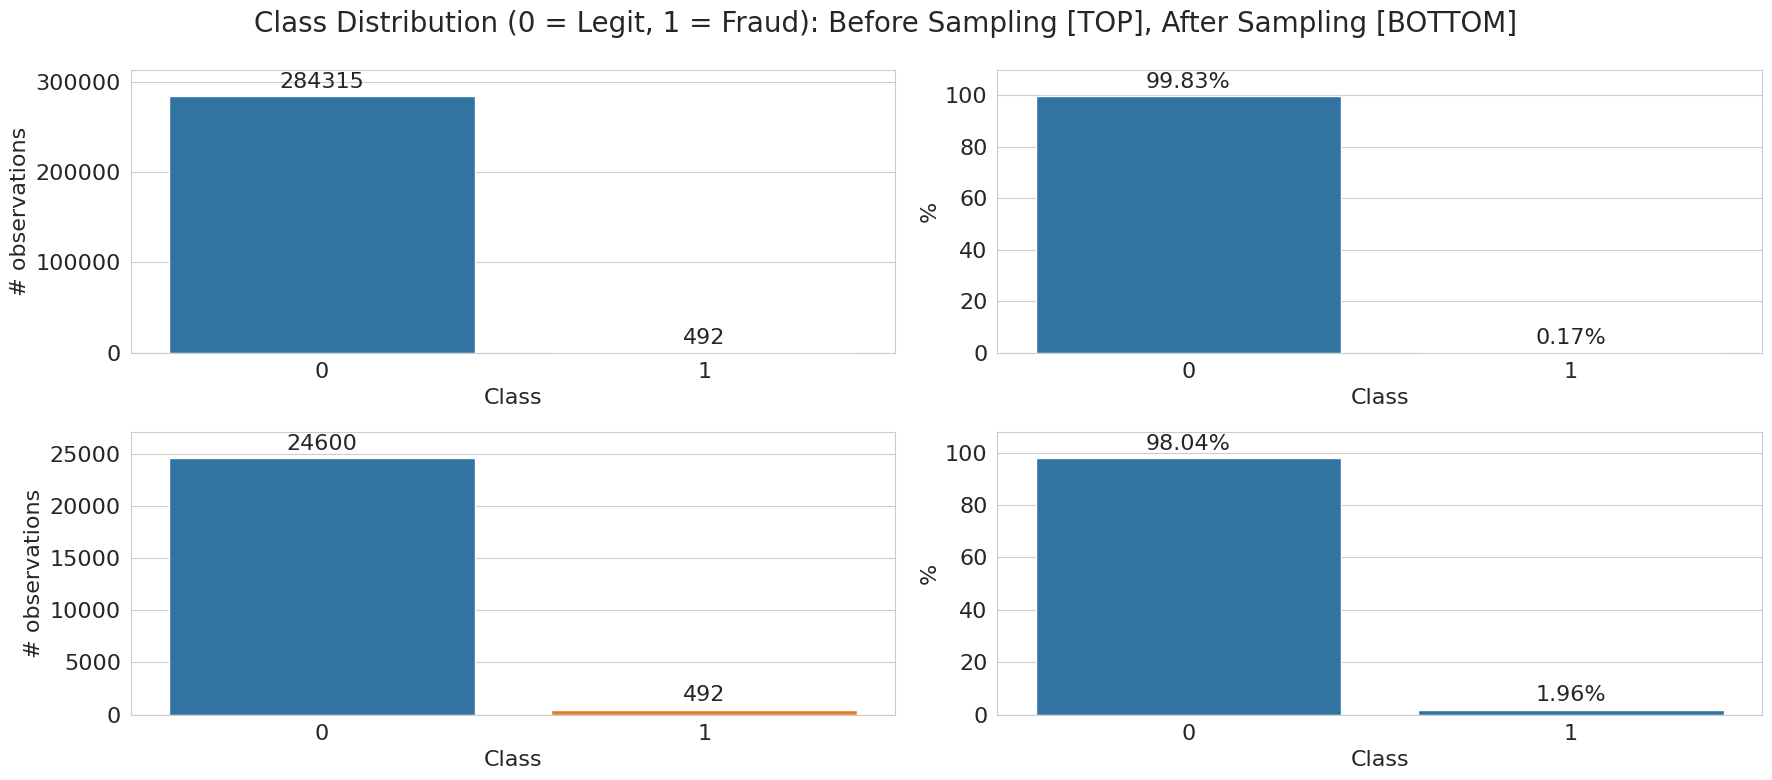

In [7]:
###### BEFORE SAMPLING ######
class_counts_before = df_before["Class"].value_counts().sort_index()
total = class_counts_before.sum()
class_percentages = class_counts_before / total * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# Subplot 1: Counting the observations per class
sns.countplot(ax=axes[0,0], data=df_before, x="Class", hue="Class", legend=False)
axes[0,0].set_xlabel("Class")
axes[0,0].set_ylabel("# observations")

for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt="%.0f", padding=3)

axes[0,0].margins(y=0.1) # Avoid clipping labels at the top

# Subplot 2: Percentage per class
sns.barplot(ax=axes[0,1], x=class_percentages.index.astype(str), y=class_percentages.values)
axes[0,1].set_xlabel("Class")
axes[0,1].set_ylabel("%")

for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt="%.2f%%", padding=3)

axes[0,1].margins(y=0.1)

###### AFTER SAMPLING ######
class_counts_after = df_after["Class"].value_counts().sort_index()
total = class_counts_after.sum()
class_percentages = class_counts_after / total * 100

# Subplot 1: Counting the observations per class
sns.countplot(ax=axes[1,0], data=df_after, x="Class", hue="Class", legend=False)
axes[1,0].set_xlabel("Class")
axes[1,0].set_ylabel("# observations")

for container in axes[1,0].containers:
    axes[1,0].bar_label(container, fmt="%.0f", padding=3)

axes[1,0].margins(y=0.1) # Avoid clipping labels at the top

# Subplot 2: Percentage per class
sns.barplot(ax=axes[1,1], x=class_percentages.index.astype(str), y=class_percentages.values)
axes[1,1].set_xlabel("Class")
axes[1,1].set_ylabel("%")

for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt="%.2f%%", padding=3)

axes[1,1].margins(y=0.1)

plt.suptitle("Class Distribution (0 = Legit, 1 = Fraud): Before Sampling [TOP], After Sampling [BOTTOM]", fontsize=20)
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "class_distribution_absolute_vs_percentage.png", dpi=300)
plt.show()

Since we pick all the samples of the fraud class (1), the next steps focus only on the class (0).

In [8]:
df_before_legit = df_before[df_before["Class"] == 0]
df_before_legit.insert(0, "Sampled", "Before")
df_before_legit.head()

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,Before,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,Before,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,Before,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,Before,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,Before,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df_after_legit = df_after[df_after["Class"] == 0]
df_after_legit.insert(0, "Sampled", "After")
df_after_legit.head()

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,After,169790.0,0.028461,0.538008,-1.189639,-1.728142,2.924734,3.405879,0.346743,0.924507,-0.166735,-0.389355,-0.199630,0.031348,-0.374201,0.354313,0.041403,-0.154184,-0.482673,-0.841395,-0.207051,0.028567,-0.264529,-0.716519,0.114845,0.688196,-0.459113,0.161854,0.264431,0.090440,4.48,0
1,After,121964.0,1.865056,0.109345,-1.909325,1.288882,0.627036,-1.156330,0.920360,-0.490938,-0.273022,0.301637,-0.325104,0.515922,0.327659,0.750602,0.205994,-0.557768,-0.301518,-0.630574,-0.611040,-0.051299,0.207311,0.488730,-0.016045,1.103365,0.411422,-0.549101,-0.048100,-0.035825,99.00,0
2,After,73793.0,-4.585760,-5.612371,3.186011,4.768080,3.871607,-2.128684,-3.642232,0.855223,0.443395,1.249705,0.261430,0.308489,-1.391363,-0.427850,-1.209373,-0.685064,0.600064,0.886108,1.462790,2.075932,0.581873,0.329566,1.119250,0.515459,0.591189,0.473995,-0.104047,-0.033810,176.18,0
3,After,79519.0,1.273467,-0.534305,0.429105,-0.996604,-0.668688,0.184996,-0.775305,0.256460,2.117505,-1.077707,-1.377496,-0.316684,-1.409105,0.122587,1.764962,-0.369872,-0.145322,0.254254,0.587320,-0.222565,-0.068432,0.018451,-0.112291,-0.952018,0.510127,-0.589343,0.098846,0.018401,1.00,0
4,After,52192.0,-0.640817,1.582395,-0.269021,0.877050,0.324550,-0.726183,0.662470,0.185684,-0.638002,0.320030,-0.193327,0.939933,1.387542,0.454260,0.761915,-0.814082,0.200900,-0.722937,-0.003071,0.050570,0.185674,0.816965,0.200717,0.121892,-0.646387,-0.389874,0.343774,0.203173,8.99,0


In [10]:
df_compare = pd.concat([df_before_legit, df_after_legit], axis=0, ignore_index=True)
df_compare.head(5)

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,Before,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,Before,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,Before,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,Before,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,Before,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df_compare.tail(5)

,Sampled,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
308910,After,58918.0,0.958687,-1.901396,0.427521,-1.302234,-1.774474,-0.163723,-0.917597,-0.115949,-2.060627,1.432821,1.114511,0.372251,1.901776,-0.517581,0.055791,0.117351,-0.062437,0.806083,-0.123320,0.334643,0.147852,0.256195,-0.306400,0.057176,0.299034,-0.133945,0.005110,0.063608,282.0,0
308911,After,83206.0,-1.464658,0.736234,2.020362,0.290575,-0.391890,-0.375046,0.182042,0.615163,-0.501685,-1.041104,-0.421012,-0.192480,-0.738587,0.493119,0.920352,0.385420,-0.221727,-0.111950,-1.614785,-0.117757,0.305150,0.498202,-0.123988,0.376237,0.411137,-0.375775,-0.066239,-0.030260,60.0,0
308912,After,164776.0,1.947737,0.009899,-1.244776,1.302383,0.040133,-1.067379,0.301814,-0.311473,0.330881,0.328189,-0.865231,-0.142368,-0.600555,0.643363,0.646478,-0.061264,-0.526809,-0.009001,-0.695012,-0.237873,0.279370,0.832769,-0.026910,-0.020475,0.268850,-0.425449,-0.005599,-0.046730,42.8,0
308913,After,79364.0,0.930286,-2.202890,1.557044,-0.826056,-2.782535,0.110230,-1.752630,0.213076,-0.728318,1.109309,-0.357035,-0.702508,-0.066964,-0.973611,0.294427,-0.659963,1.113278,-0.018224,-0.943922,0.030772,0.195556,0.697675,-0.124311,0.624344,0.047619,-0.010963,0.075040,0.075741,229.0,0
308914,After,158726.0,-0.250647,1.256809,-0.597791,-0.395273,0.365264,-1.047786,0.648729,0.314284,-0.239916,-1.074836,-0.400077,0.162398,-0.098049,-0.650637,-0.253904,0.270211,0.758470,-0.398340,-0.477376,-0.090966,-0.257932,-0.746864,0.243248,0.978742,-0.469632,0.091807,0.095895,0.026801,16.0,0


## Comparing Amount Distribution

Let's first compare very quickly some basic statistics for `Amount`.

In [12]:
df_compare.groupby("Sampled", observed=True)["Amount"].describe().sort_values(by="Sampled", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Sampled,,,,,,,,
Before,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
After,24600.0,85.823007,213.902563,0.0,5.49,21.94,75.95,6511.00


In [13]:
df_compare.groupby("Sampled", observed=True)["Amount"].skew().sort_index(ascending=False)

Sampled
Before    17.003147
After      8.227490
Name: Amount, dtype: float64

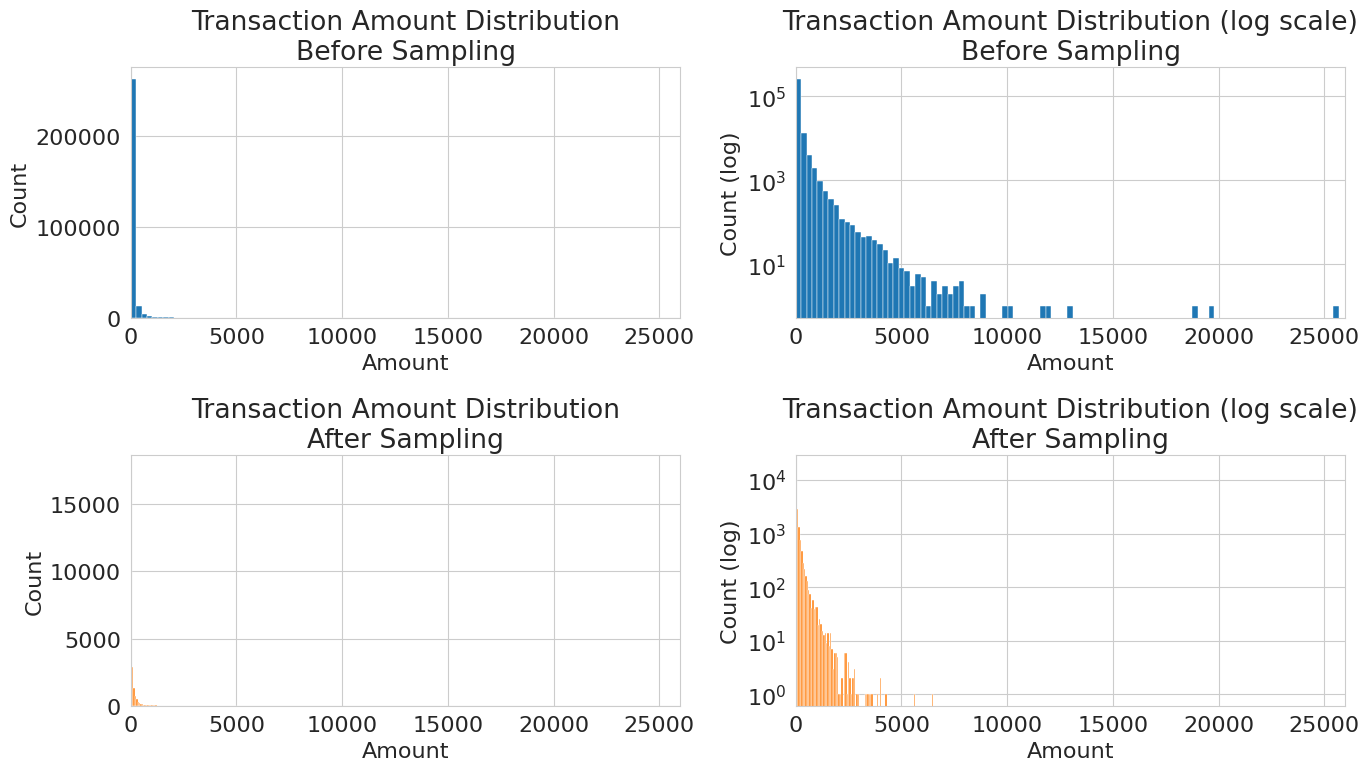

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_compare[df_compare["Sampled"] == "Before"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             fill=True,
             ax=axes[0,0])
axes[0,0].set_xlim(0, 26000)
axes[0,0].set_title("Transaction Amount Distribution\nBefore Sampling")

sns.histplot(df_compare[df_compare["Sampled"] == "Before"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             ax=axes[0,1])
axes[0,1].set_xlim(0, 26000)
axes[0,1].set_yscale("log")
axes[0,1].set_ylabel("Count (log)")
axes[0,1].set_title("Transaction Amount Distribution (log scale)\nBefore Sampling")

sns.histplot(df_compare[df_compare["Sampled"] == "After"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1,0])
axes[1,0].set_xlim(0, 26000)
axes[1,0].set_title("Transaction Amount Distribution\nAfter Sampling")

sns.histplot(df_compare[df_compare["Sampled"] == "After"]["Amount"],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1,1])
axes[1,1].set_xlim(0, 26000)
axes[1,1].set_yscale("log")
axes[1,1].set_ylabel("Count (log)")
axes[1,1].set_title("Transaction Amount Distribution (log scale)\nAfter Sampling")

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "amount_distribution_log_scale_by_class.png", dpi=300)
plt.show()

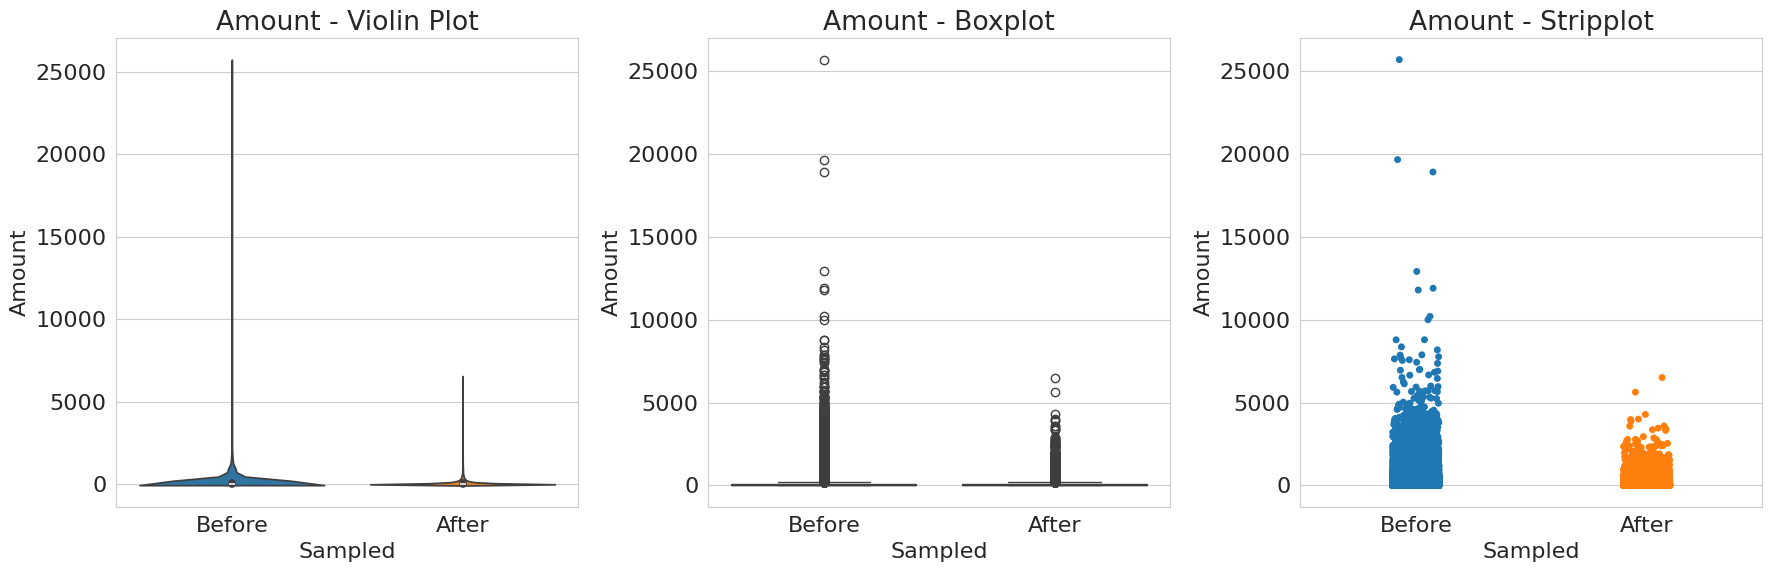

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.violinplot(data=df_compare,
               x="Sampled",
               y="Amount",
               hue="Sampled",
               ax=axes[0],
               legend=False)
axes[0].set_title("Amount - Violin Plot")

sns.boxplot(data=df_compare,
            x="Sampled",
            y="Amount",
            hue="Sampled",
            ax=axes[1],
            legend=False)
axes[1].set_title("Amount - Boxplot")

sns.stripplot(data=df_compare,
              x="Sampled",
              y="Amount",
              hue="Sampled",
              ax=axes[2],
              legend=False)
axes[2,].set_title("Amount - Stripplot")

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "amount_violin_box_strip_plot.png", dpi=300)
plt.show()

In [16]:
out = ks_two_sample(df_compare[df_compare["Sampled"] == "Before"]["Amount"],
                    df_compare[df_compare["Sampled"] == "After"]["Amount"])
print(f"KS D={out['D']:.4f}, p={out['p']:.3e} (n_x={out['n_x']}, n_y={out['n_y']})")

KS D=0.0032, p=9.745e-01 (n_x=284315, n_y=24600)


The K-S test's null hypothesis ($H_0$) is that both samples (your population and your new sample) are drawn from the same distribution.

The Test: We compare the p-value to a significance level ($\alpha = 0.05$).

Interpretation: The returned p-value (0.9745) is much, much larger than 0.05.When the p-value is high, we fail to reject the null hypothesis.

We have no statistical evidence to say that the two distributions are different. We can assume they are the same.This is especially powerful given your large sample sizes. Large samples are very sensitive and can often find tiny, statistically significant (but practically meaningless) differences. The fact that this test still found no significant difference is a very strong positive

---

The K-S Statistic (D = 0.0032) confirms the p-value's result. The D statistic measures the maximum difference between the two cumulative distribution curves. A value of 0.0032 means that at their point of greatest divergence, the two distribution curves are only 0.32% apart. This difference is minuscule and practically non-existent.

## Comparing PCA Feature (V1-V28) Distribution

In [17]:
pcs_cols_name = [f"V{i}" for i in range(1, 29)]

# Melt the DataFrame to a long format. This stacks all V1...V28 columns into two columns:
# 'Feature' (with values like 'V1', 'V2') and 'Value'
df_melted = df_compare.melt(id_vars=["Sampled"],
                            value_vars=pcs_cols_name,
                            var_name="Feature",
                            value_name="Value")

# Group by 'Feature' first, then 'Sampled', and get stats
df_melted.groupby(["Feature", "Sampled"])["Value"].describe()

count      mean       std         min       25%       50%  \
Feature Sampled                                                                 
V1      After     24600.0  0.011386  1.876337  -30.515455 -0.915863  0.019062   
        Before   284315.0  0.008258  1.929814  -56.407510 -0.917544  0.020023   
V10     After     24600.0  0.005048  1.035049  -10.585366 -0.534381 -0.095307   
        Before   284315.0  0.009824  1.044204  -14.741096 -0.532880 -0.091872   
V11     After     24600.0 -0.004032  0.998226   -3.423222 -0.759960 -0.032194   
        Before   284315.0 -0.006576  1.003112   -4.797473 -0.763447 -0.034923   
V12     After     24600.0  0.019766  0.939457  -13.884393 -0.395244  0.150546   
        Before   284315.0  0.010832  0.945939  -15.144988 -0.402102  0.141679   
V13     After     24600.0 -0.005353  0.988038   -3.642446 -0.652750 -0.029009   
        Before   284315.0  0.000189  0.995067   -5.791881 -0.648067 -0.013547   
V14     After     24600.0  0.006752  0.900969  -11.887174 -0.425834  0.050917   
        Before   284315.0  0.012064  0.897007  -18.392091 -0.422453  0.051947   
V15     After     24600.0 -0.001937  0.922349   -3.936008 -0.593661  0.044770   
        Before   284315.0  0.000161  0.915060   -4.391307 -0.582812  0.048294   
V16     After     24600.0  0.005199  0.838406   -9.272107 -0.465294  0.064621   
        Before   284315.0  0.007164  0.844772  -10.115560 -0.465543  0.067377   
V17     After     24600.0  0.014802  0.754115  -15.724715 -0.482788 -0.059834   
        Before   284315.0  0.011535  0.749457  -17.098444 -0.482644 -0.064833   
V18     After     24600.0  0.004520  0.823129   -5.023331 -0.498187 -0.004360   
        Before   284315.0  0.003887  0.824919   -5.366660 -0.497414 -0.002787   
V19     After     24600.0  0.004541  0.807908   -4.366767 -0.453331  0.003015   
        Before   284315.0 -0.001178  0.811733   -7.213527 -0.456366  0.003117   
V2      After     24600.0  0.001473  1.558133  -32.494845 -0.604635  0.066261   
        Before   284315.0 -0.006271  1.636146  -72.715728 -0.599473  0.064070   
V20     After     24600.0 -0.000299  0.707866  -23.646890 -0.213608 -0.063377   
        Before   284315.0 -0.000644  0.769404  -54.497720 -0.211764 -0.062646   
V21     After     24600.0 -0.006408  0.685045  -14.058810 -0.227836 -0.029222   
        Before   284315.0 -0.001235  0.716743  -34.830382 -0.228509 -0.029821   
V22     After     24600.0  0.000242  0.717749   -5.435919 -0.551009  0.006597   
        Before   284315.0 -0.000024  0.723668  -10.933144 -0.542403  0.006736   
V23     After     24600.0  0.003139  0.569943  -17.530682 -0.162647 -0.009835   
        Before   284315.0  0.000070  0.621541  -44.807735 -0.161702 -0.011147   
V24     After     24600.0 -0.003821  0.608727   -2.836627 -0.354796  0.040045   
        Before   284315.0  0.000182  0.605776   -2.836627 -0.354425  0.041082   
V25     After     24600.0 -0.006400  0.520039   -4.541819 -0.320544  0.013150   
        Before   284315.0 -0.000072  0.520673  -10.295397 -0.317145  0.016417   
V26     After     24600.0  0.002488  0.485078   -1.581931 -0.328337 -0.047615   
        Before   284315.0 -0.000089  0.482241   -2.604551 -0.327074 -0.052227   
V27     After     24600.0 -0.000960  0.397041   -9.543518 -0.070827  0.001297   
        Before   284315.0 -0.000295  0.399847  -22.565679 -0.070852  0.001230   
V28     After     24600.0  0.000093  0.310421   -8.307955 -0.052479  0.011360   
        Before   284315.0 -0.000131  0.329570  -15.430084 -0.052950  0.011199   
V3      After     24600.0  0.010574  1.431958  -13.084379 -0.889440  0.175480   
        Before   284315.0  0.012171  1.459429  -48.325589 -0.884541  0.182158   
V4      After     24600.0 -0.005668  1.385981   -4.938824 -0.839589 -0.019490   
        Before   284315.0 -0.007860  1.399333   -5.683171 -0.850077 -0.022405   
V5      After     24600.0  0.020394  1.316417  -22.325816 -0.683215 -0.053390   
        Before   284315.0  0.005453  1.356952 -113.

In [18]:
df_melted.groupby(["Feature", "Sampled"])["Value"].skew()

Feature  Sampled
V1       After      -2.393237
         Before     -3.130188
V10      After       2.305089
         Before      2.422278
V11      After       0.161994
         Before      0.145537
V12      After      -1.290739
         Before     -1.256301
V13      After       0.099011
         Before      0.065582
V14      After      -0.767878
         Before     -0.703857
V15      After      -0.327461
         Before     -0.307659
V16      After      -0.501033
         Before     -0.439523
V17      After       0.204053
         Before      0.224528
V18      After      -0.023302
         Before     -0.039862
V19      After       0.159394
         Before      0.097484
V2       After      -2.942463
         Before     -4.887166
V20      After      -3.530564
         Before     -2.078113
V21      After       3.139202
         Before      3.009113
V22      After      -0.086026
         Before     -0.193030
V23      After       0.393478
         Before     -5.814596
V24      After      -0.

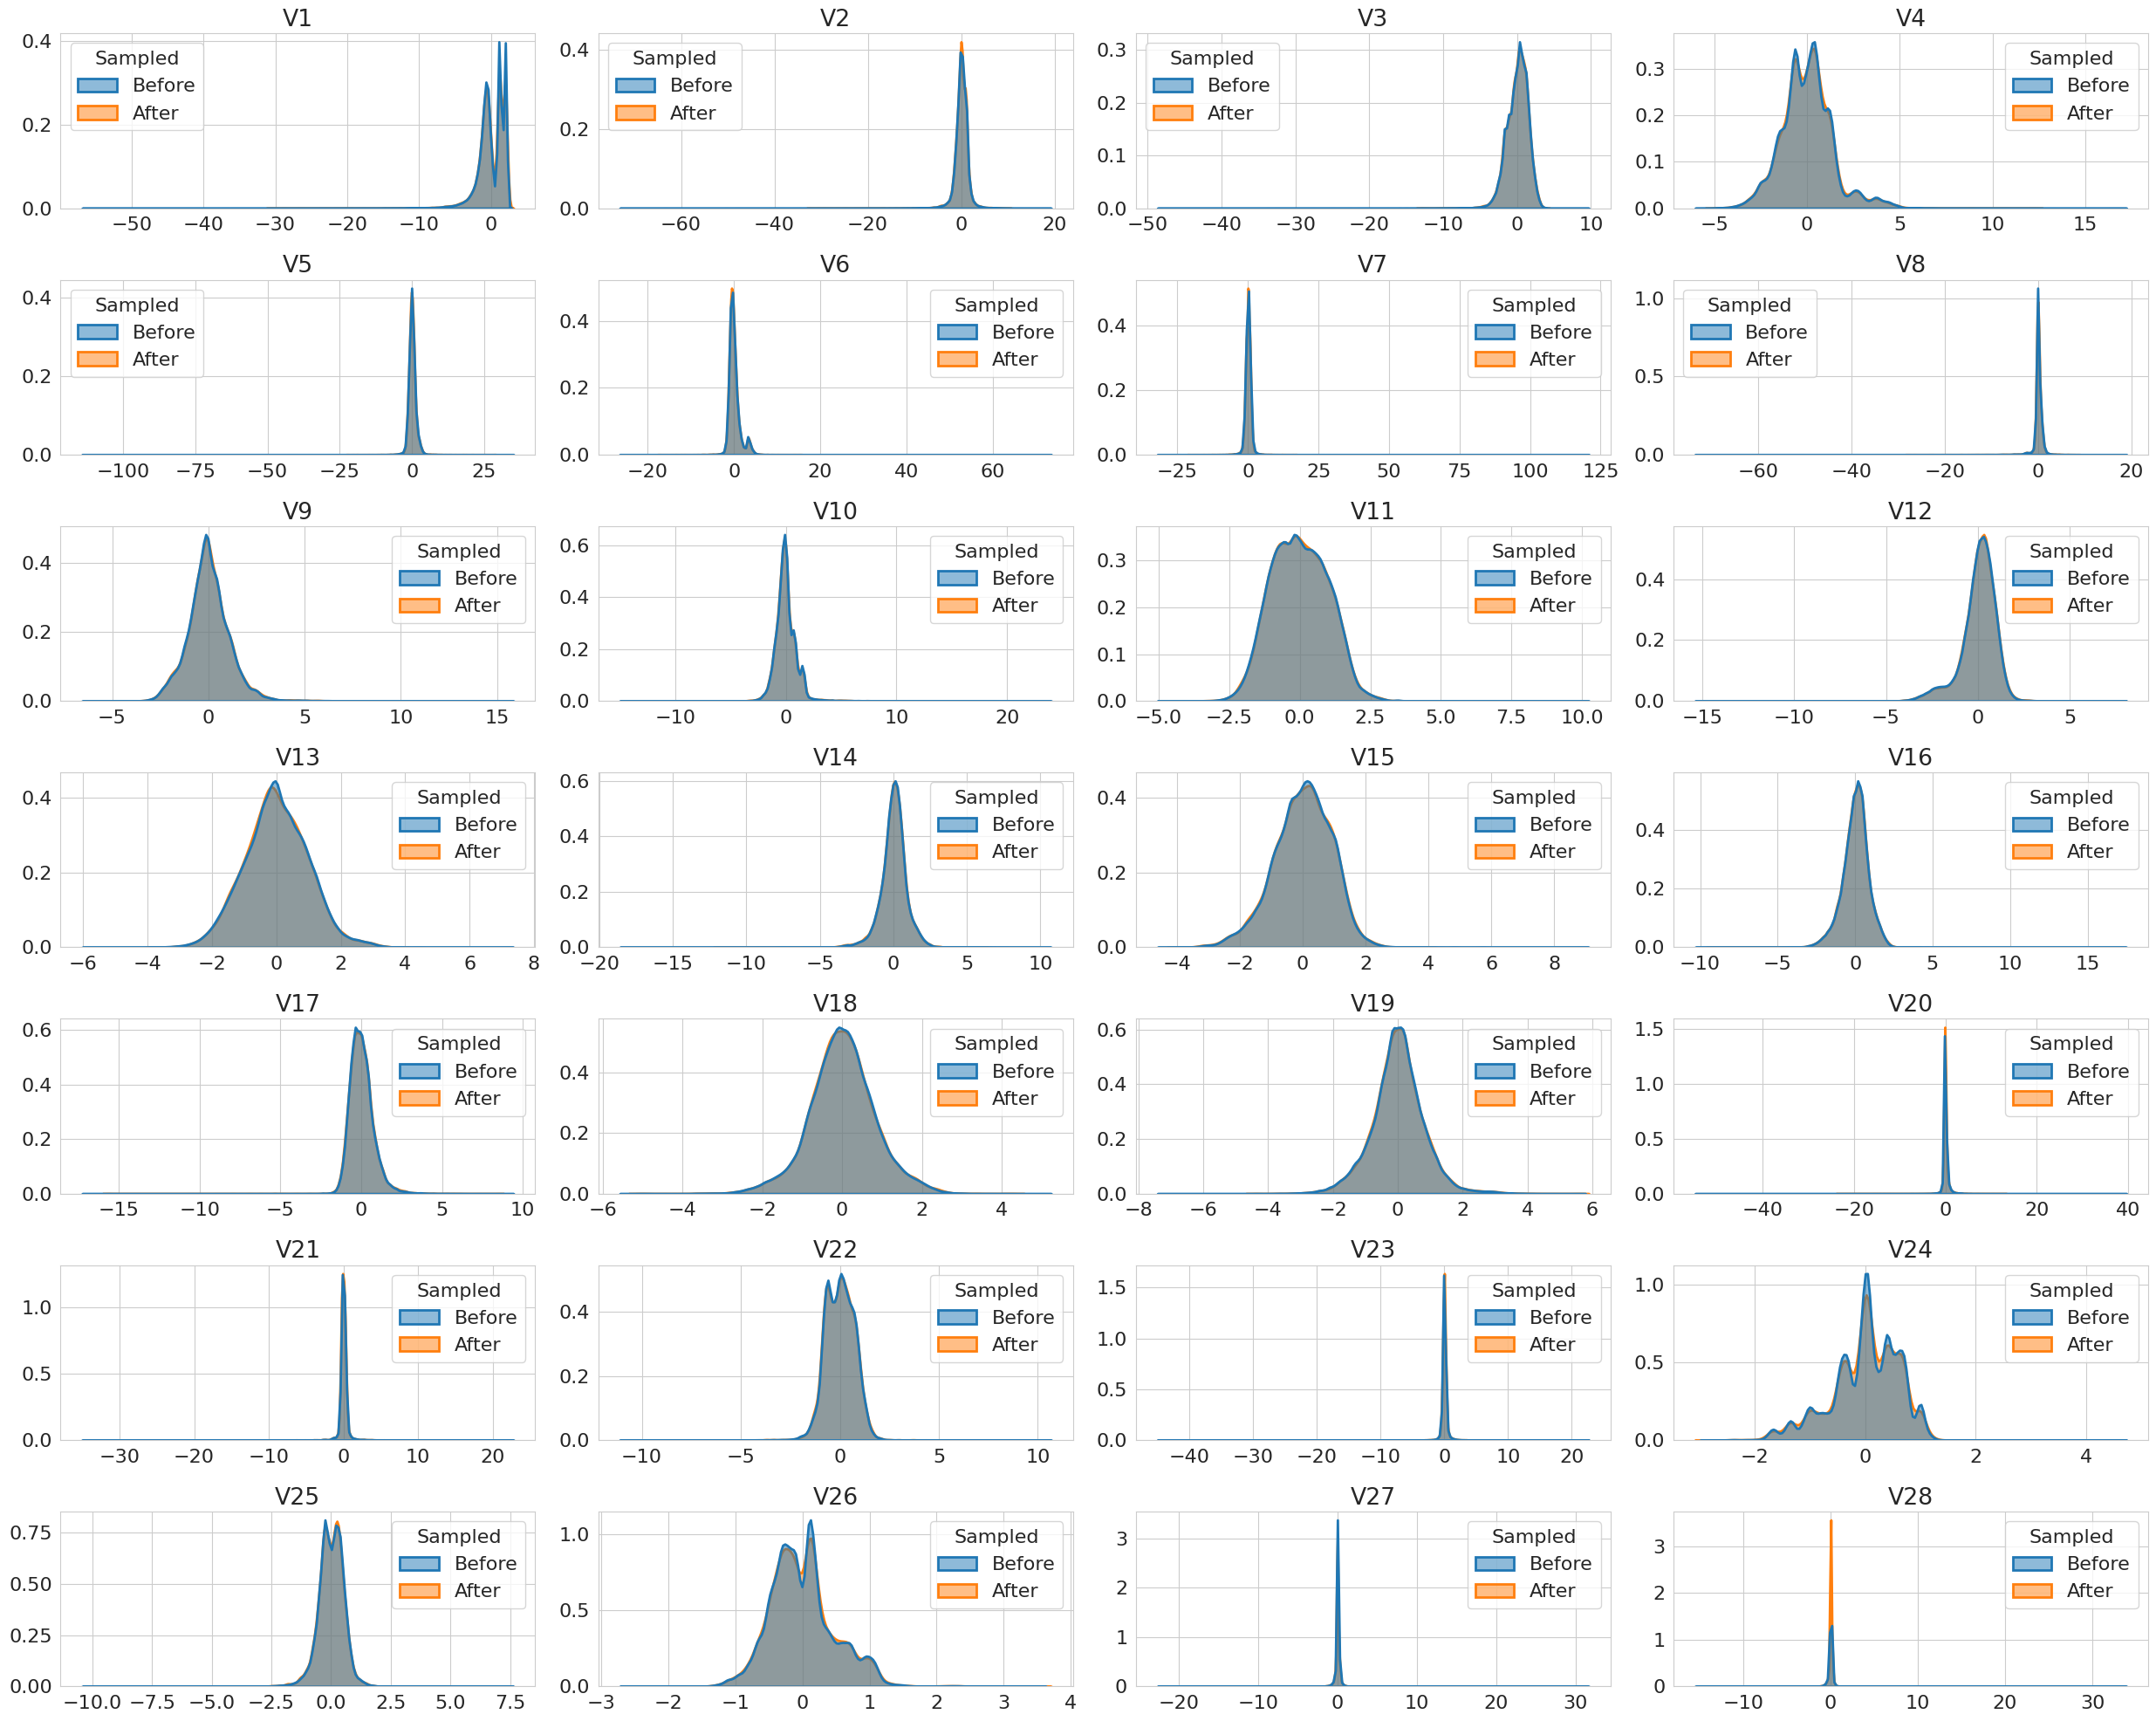

In [19]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.kdeplot(data=df_compare,
                x=col,
                hue="Sampled",
                fill=True,
                common_norm=False,
                alpha=0.5,
                linewidth=2.0,
                ax=axes[i])

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_kde.png", dpi=300)
plt.show()

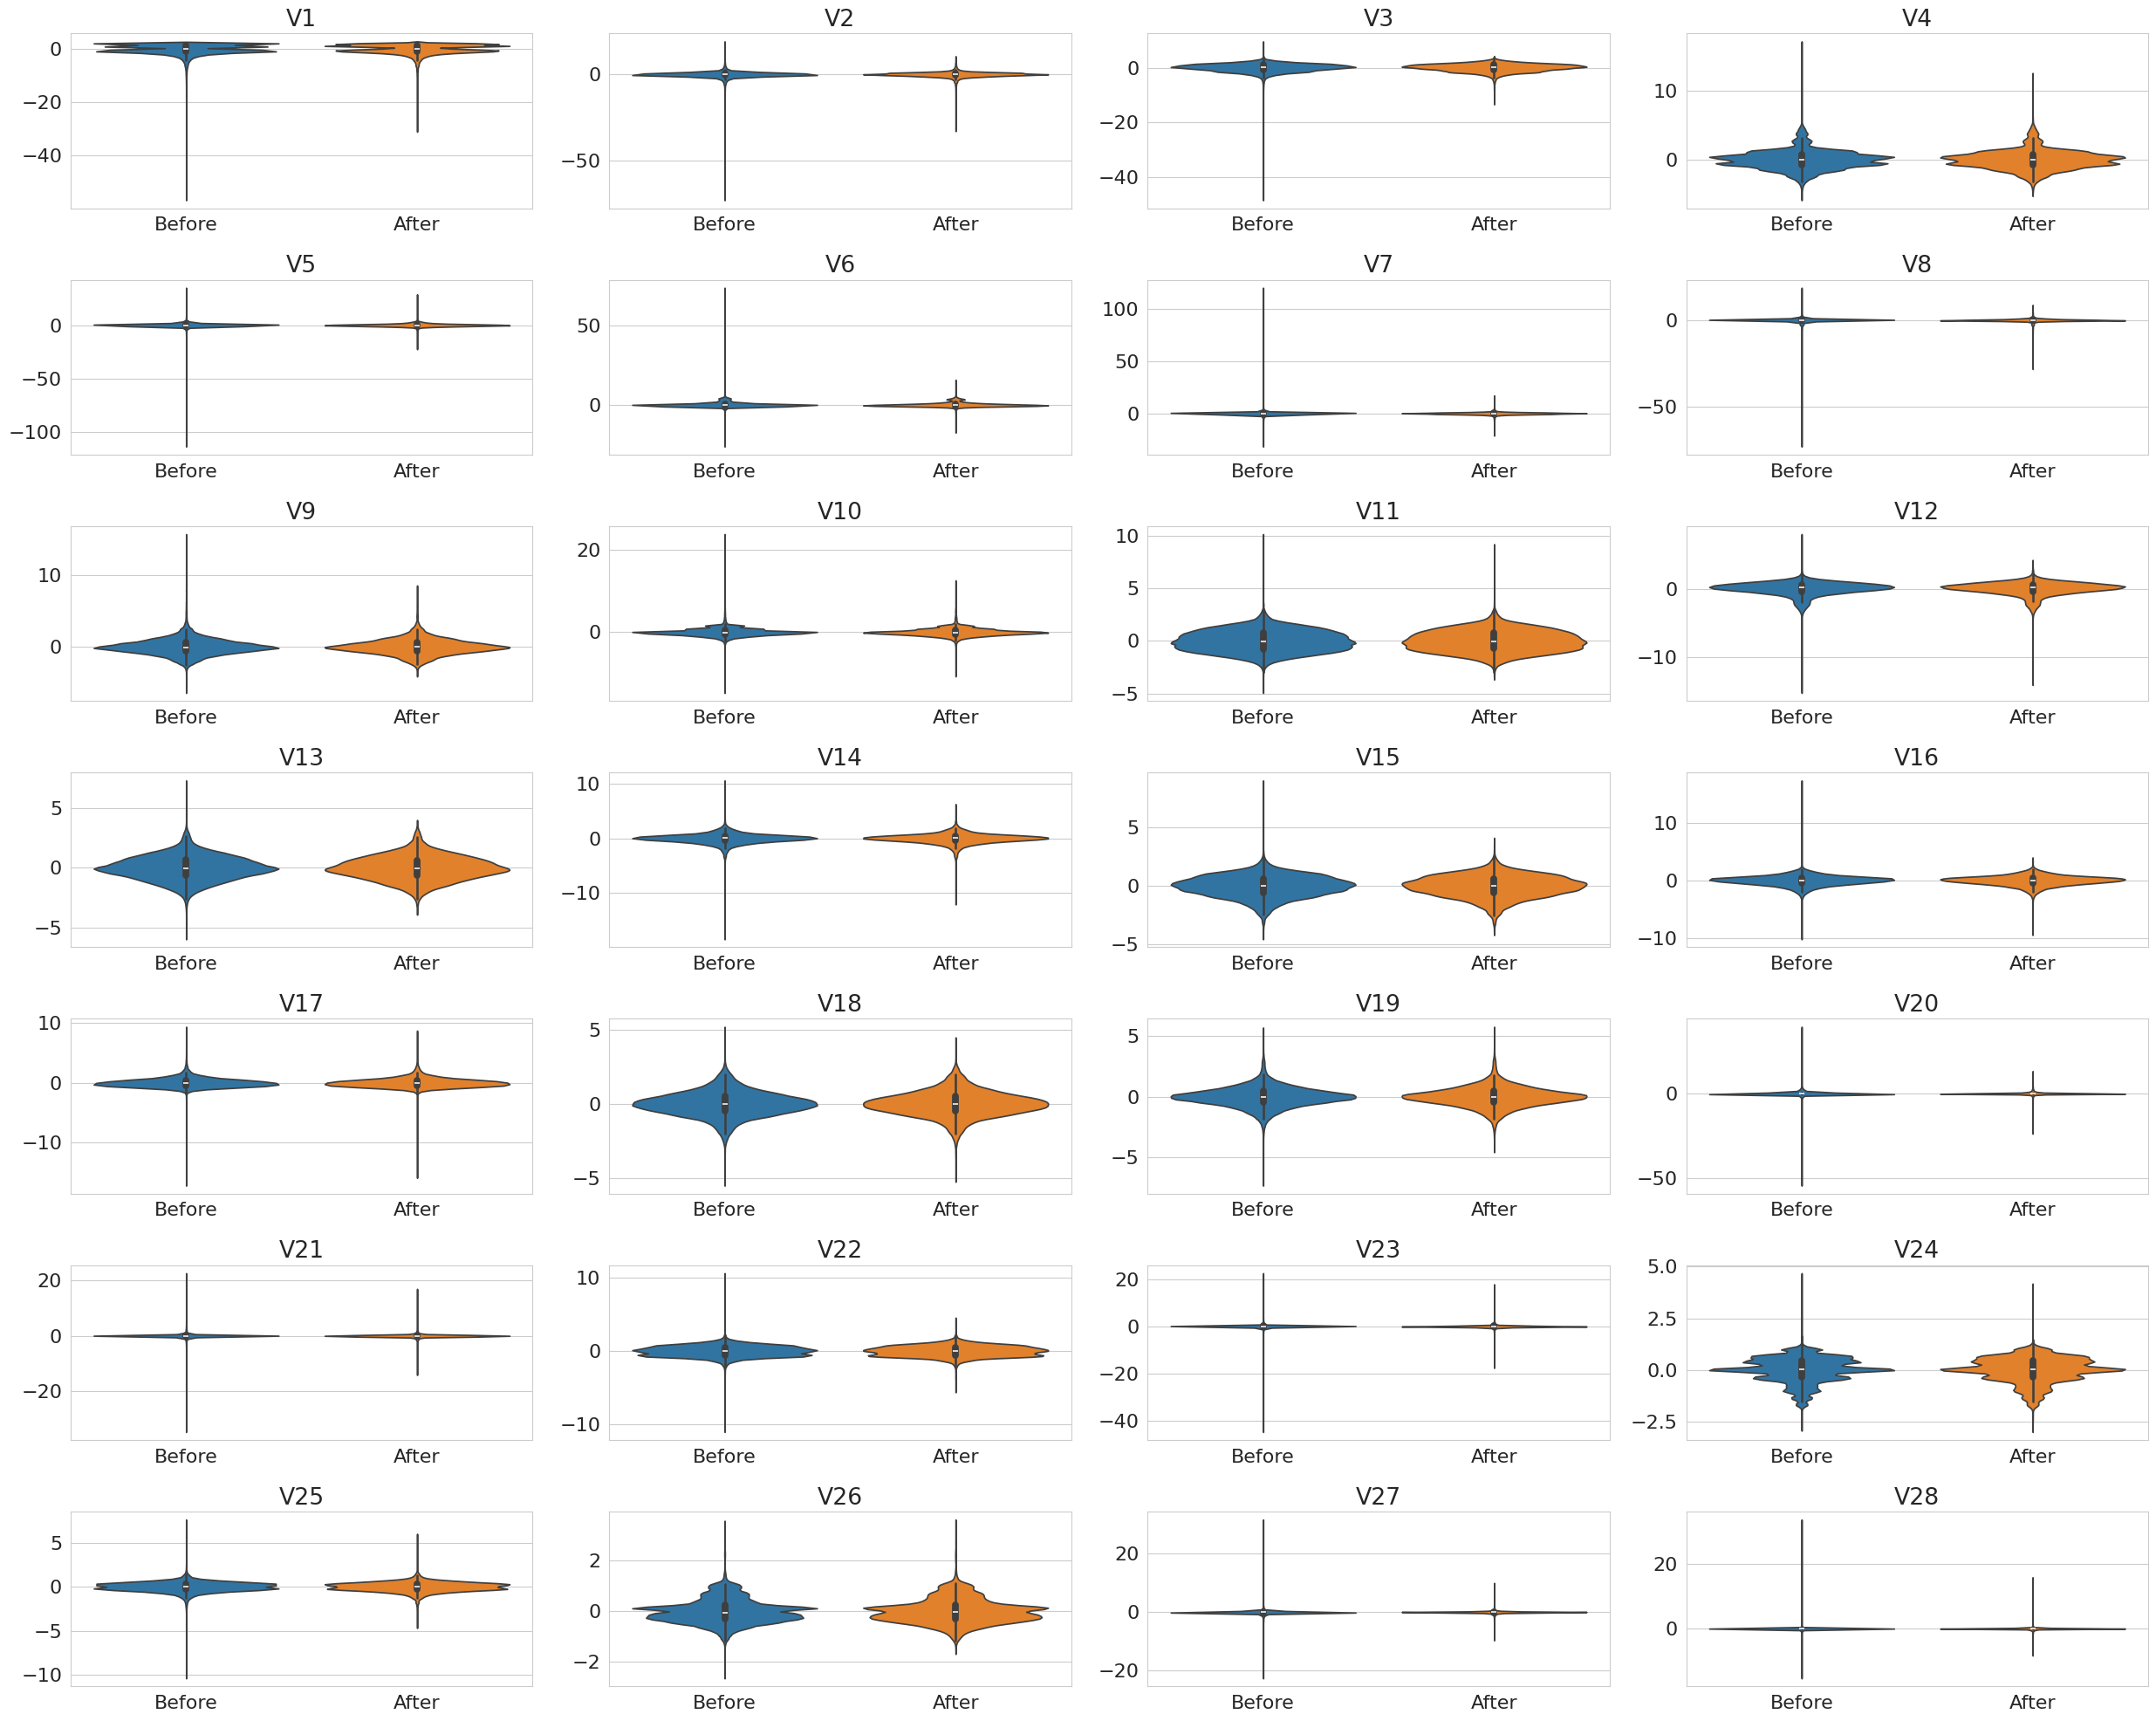

In [20]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.violinplot(data=df_compare,
                   x="Sampled",
                   y=col,
                   hue="Sampled",
                   ax=axes[i],
                   legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_violin.png", dpi=300)
plt.show()

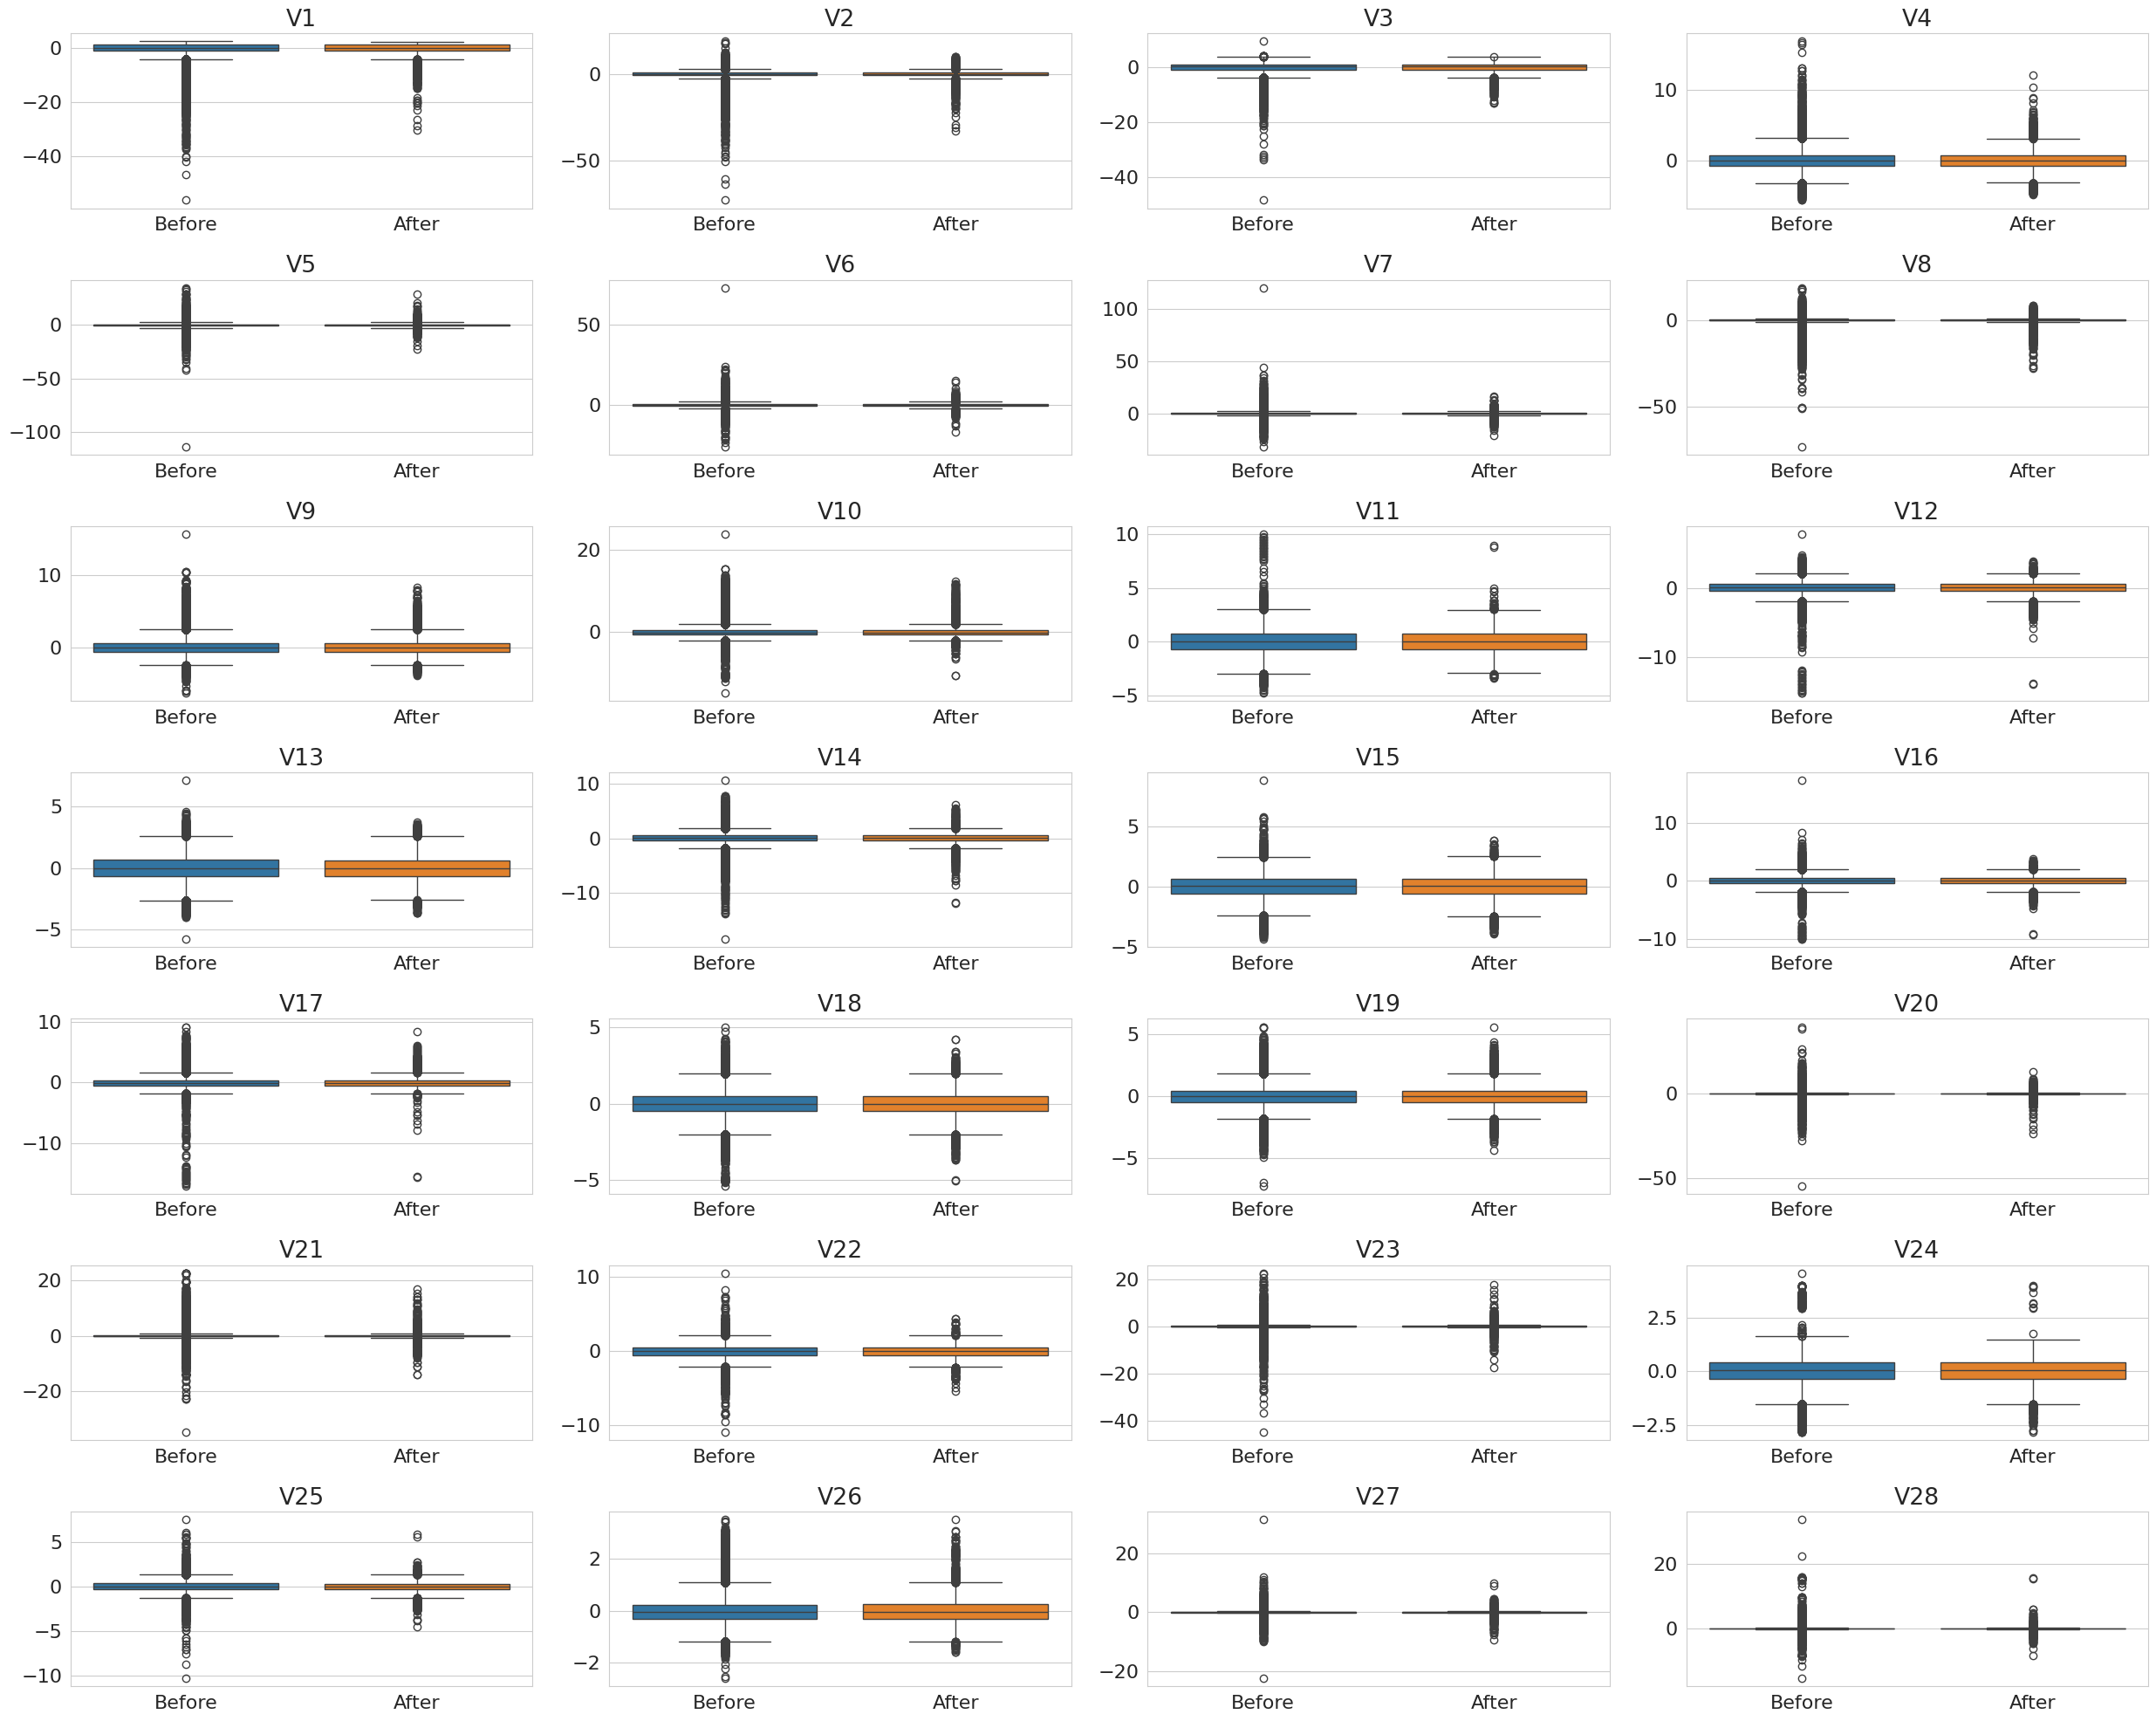

In [21]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.boxplot(data=df_compare,
                x="Sampled",
                y=col,
                hue="Sampled",
                ax=axes[i],
                legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_boxplot.png", dpi=300)
plt.show()

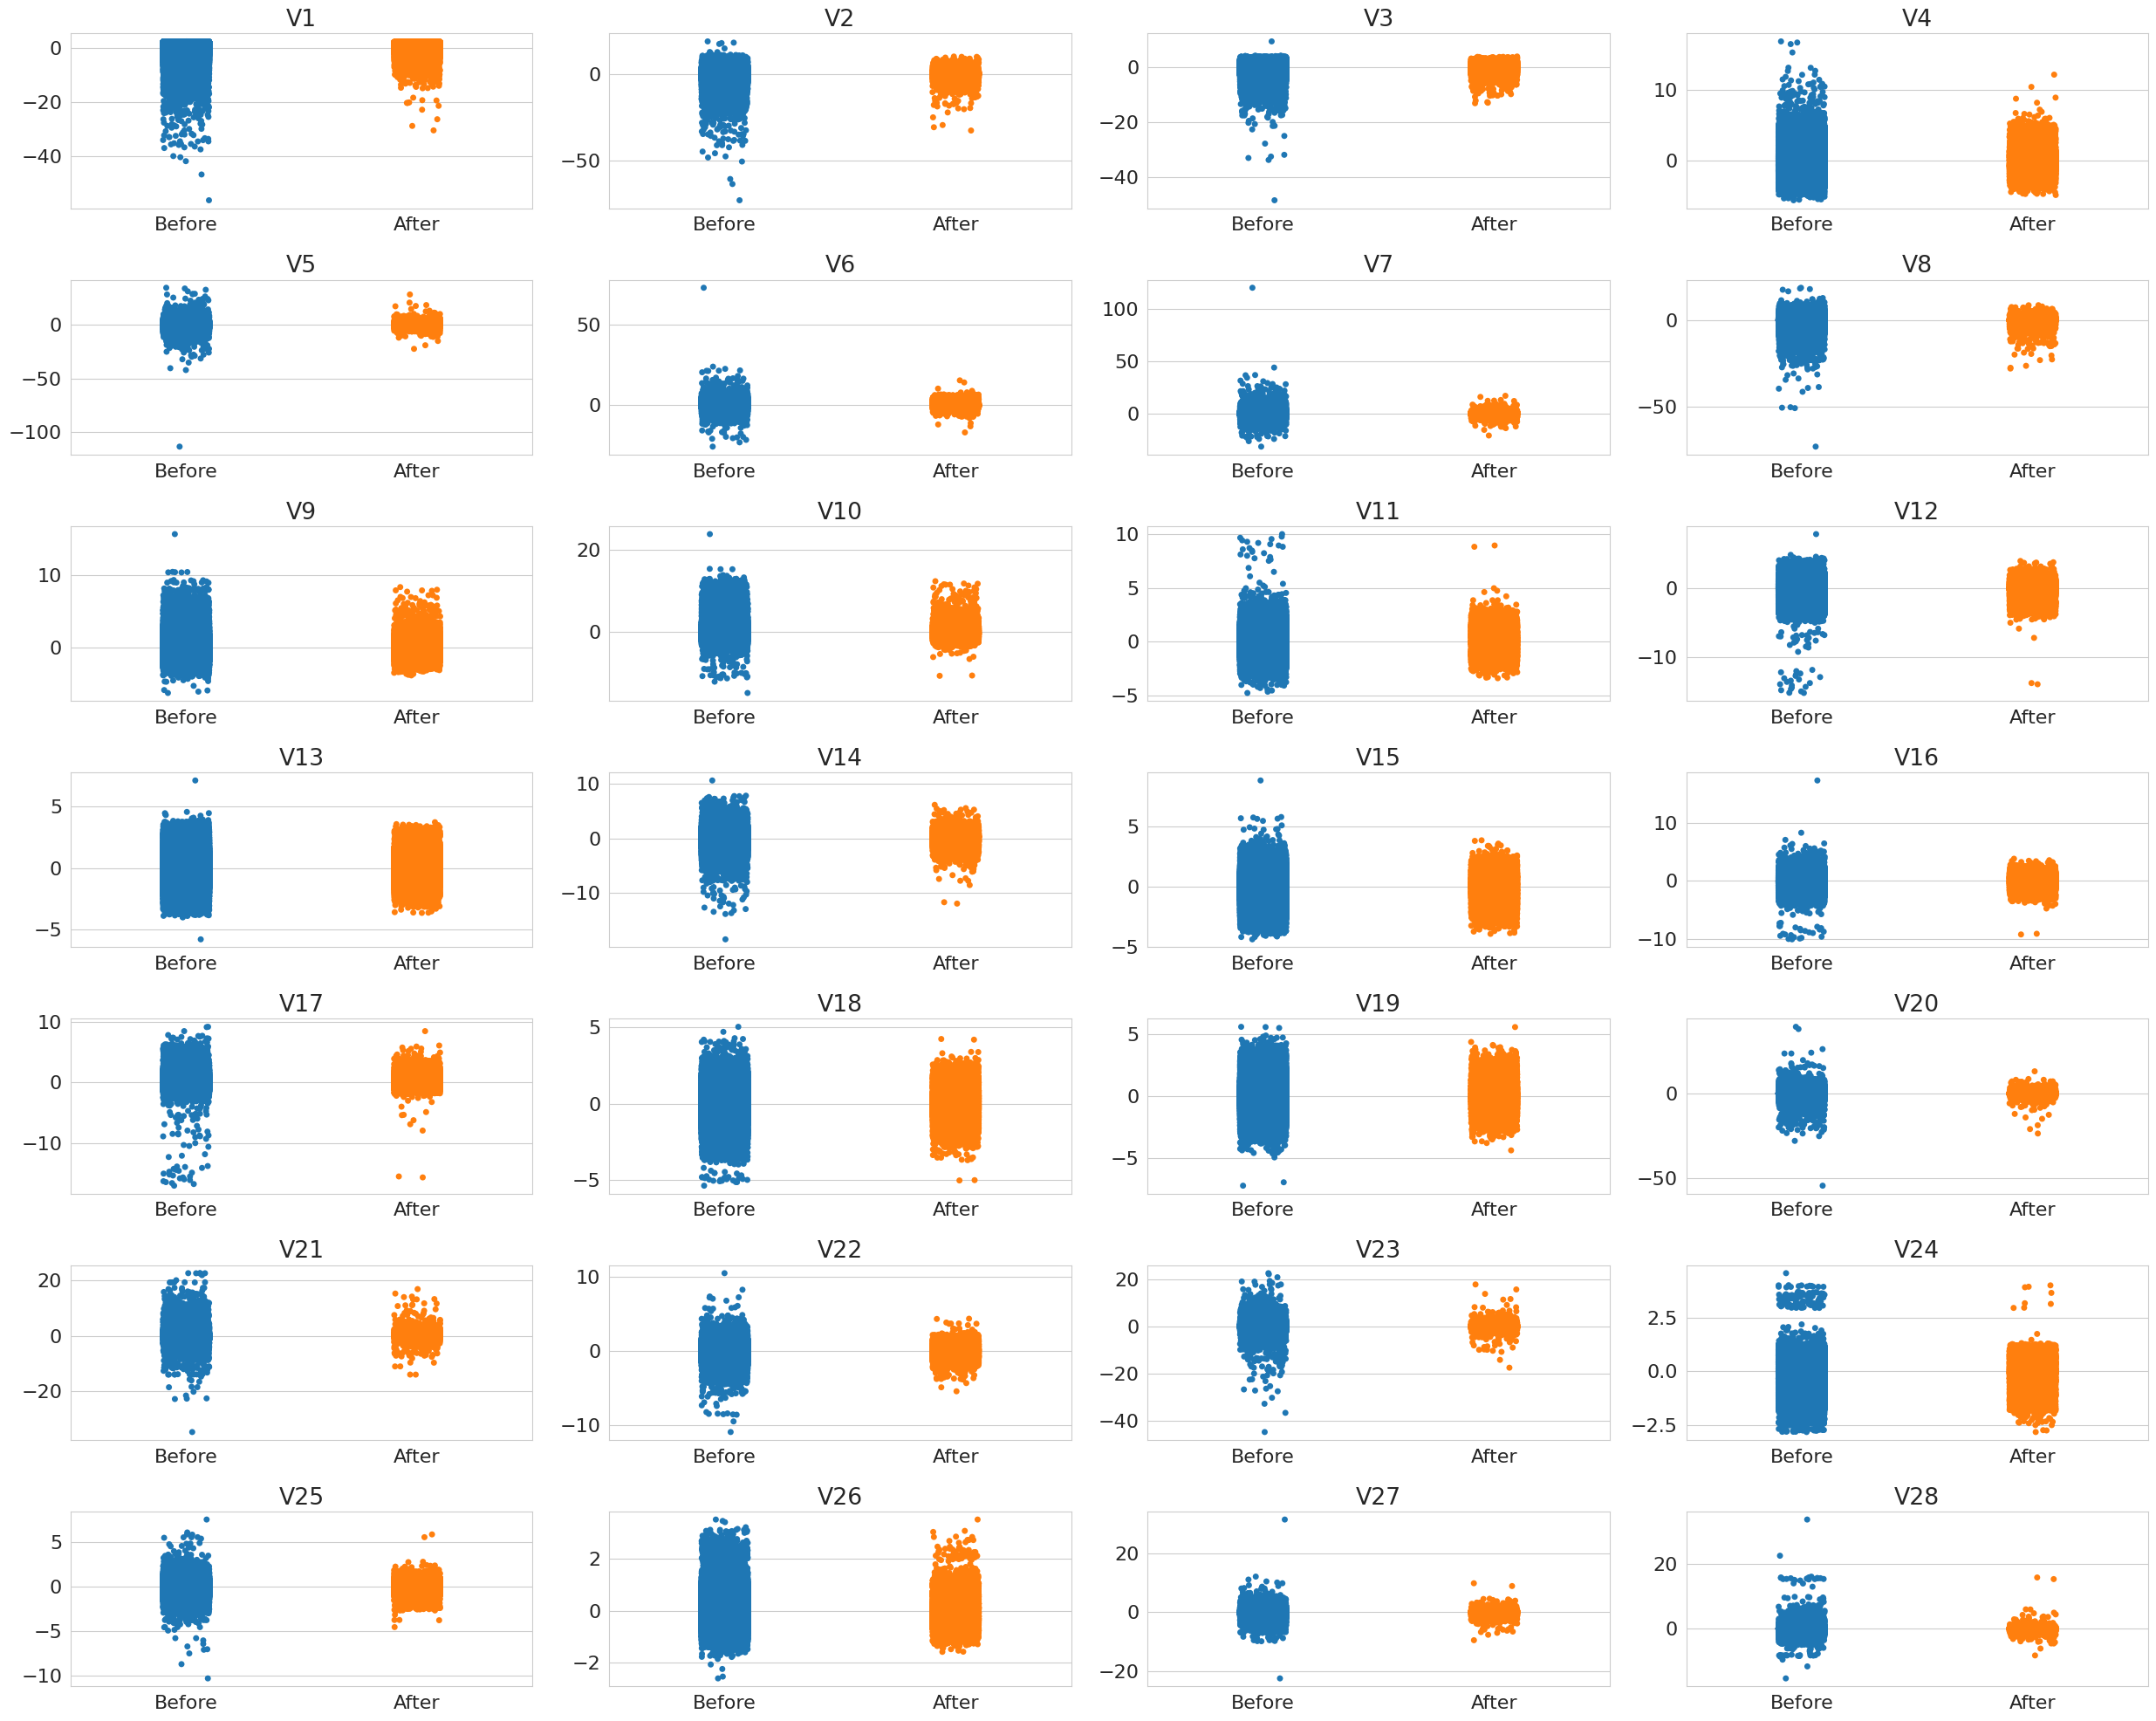

In [22]:
fig, axes = plt.subplots(7, 4, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.stripplot(data=df_compare,
                  x="Sampled",
                  y=col,
                  hue="Sampled",
                  ax=axes[i],
                  legend=False)

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "pcs_stripplot.png", dpi=300)
plt.show()

In [23]:
for _, col in enumerate(pcs_cols_name):
    out = ks_two_sample(df_compare[df_compare["Sampled"] == "Before"][col],
                        df_compare[df_compare["Sampled"] == "After"][col])

    print(f"{col:3} -- KS D={out['D']:.4f}, p={out['p']:.3e} (n_x={out['n_x']}, n_y={out['n_y']})")

V1  -- KS D=0.0032, p=9.708e-01 (n_x=284315, n_y=24600)
V2  -- KS D=0.0038, p=8.953e-01 (n_x=284315, n_y=24600)
V3  -- KS D=0.0039, p=8.785e-01 (n_x=284315, n_y=24600)
V4  -- KS D=0.0042, p=8.221e-01 (n_x=284315, n_y=24600)
V5  -- KS D=0.0047, p=6.982e-01 (n_x=284315, n_y=24600)
V6  -- KS D=0.0035, p=9.482e-01 (n_x=284315, n_y=24600)
V7  -- KS D=0.0053, p=5.583e-01 (n_x=284315, n_y=24600)
V8  -- KS D=0.0060, p=3.919e-01 (n_x=284315, n_y=24600)
V9  -- KS D=0.0062, p=3.417e-01 (n_x=284315, n_y=24600)
V10 -- KS D=0.0035, p=9.406e-01 (n_x=284315, n_y=24600)
V11 -- KS D=0.0037, p=9.069e-01 (n_x=284315, n_y=24600)
V12 -- KS D=0.0055, p=4.998e-01 (n_x=284315, n_y=24600)
V13 -- KS D=0.0091, p=4.586e-02 (n_x=284315, n_y=24600)
V14 -- KS D=0.0031, p=9.778e-01 (n_x=284315, n_y=24600)
V15 -- KS D=0.0049, p=6.383e-01 (n_x=284315, n_y=24600)
V16 -- KS D=0.0036, p=9.321e-01 (n_x=284315, n_y=24600)
V17 -- KS D=0.0050, p=6.181e-01 (n_x=284315, n_y=24600)
V18 -- KS D=0.0046, p=7.245e-01 (n_x=284315, n_y

For 26 of 28 variables, the p-value is significantly higher than the standard 0.05 threshold. For these 26 features, you fail to reject the null hypothesis ($H_0$). This means there is no statistical evidence to suggest that the sample distribution is different from the population distribution. The tiny D values (e.g., D=0.0027 for V27) confirm this, showing the maximum difference between the distributions is minuscule (e.g., 0.27%).

There Two Statistical Exceptions (V13 & V25) that are statistically significant, meaning their p-values fell below the 0.05 threshold:
- V13: KS D=0.0091, p=0.04586 (which is $< 0.05$)
- V25: KS D=0.0094, p=0.03660 (which is $< 0.05$)

Technically, for V13 and V25, you reject the null hypothesis. The test is telling you that the differences between your sample and population for these two features are unlikely to be due to random chance.

Look at the D statistics for those two "failed" tests:
- V13: $D = 0.0091$
- V25: $D = 0.0094$

This means that the maximum difference between the population and sample distributions, even for these "worst" two features, is less than 1% (0.91% and 0.94%, respectively).

## Correlation matrices

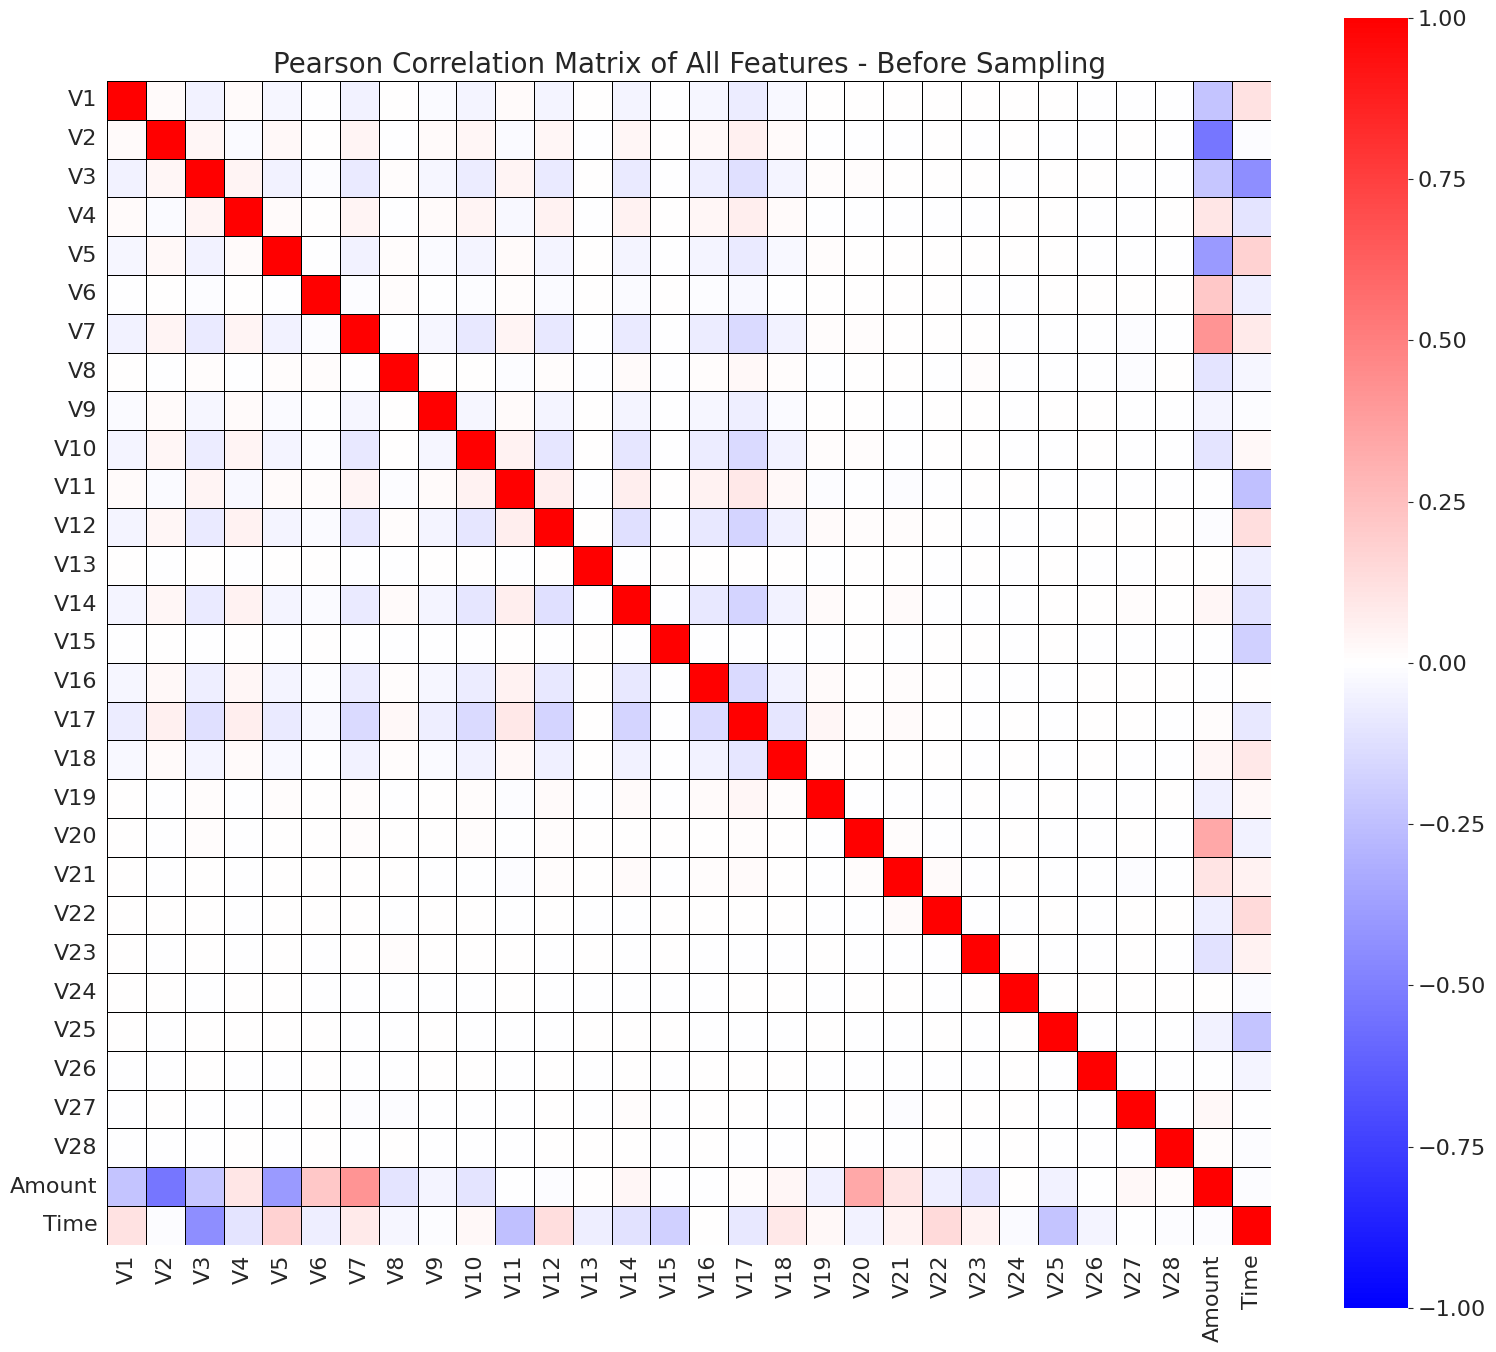

In [24]:
corr_before = df_compare.loc[df_compare["Sampled"] == "Before", pcs_cols_name + ["Amount", "Time"]].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_before,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Pearson Correlation Matrix of All Features - Before Sampling", fontsize=20)
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "all_features_correlation_matrix_before.png", dpi=300)
plt.show()

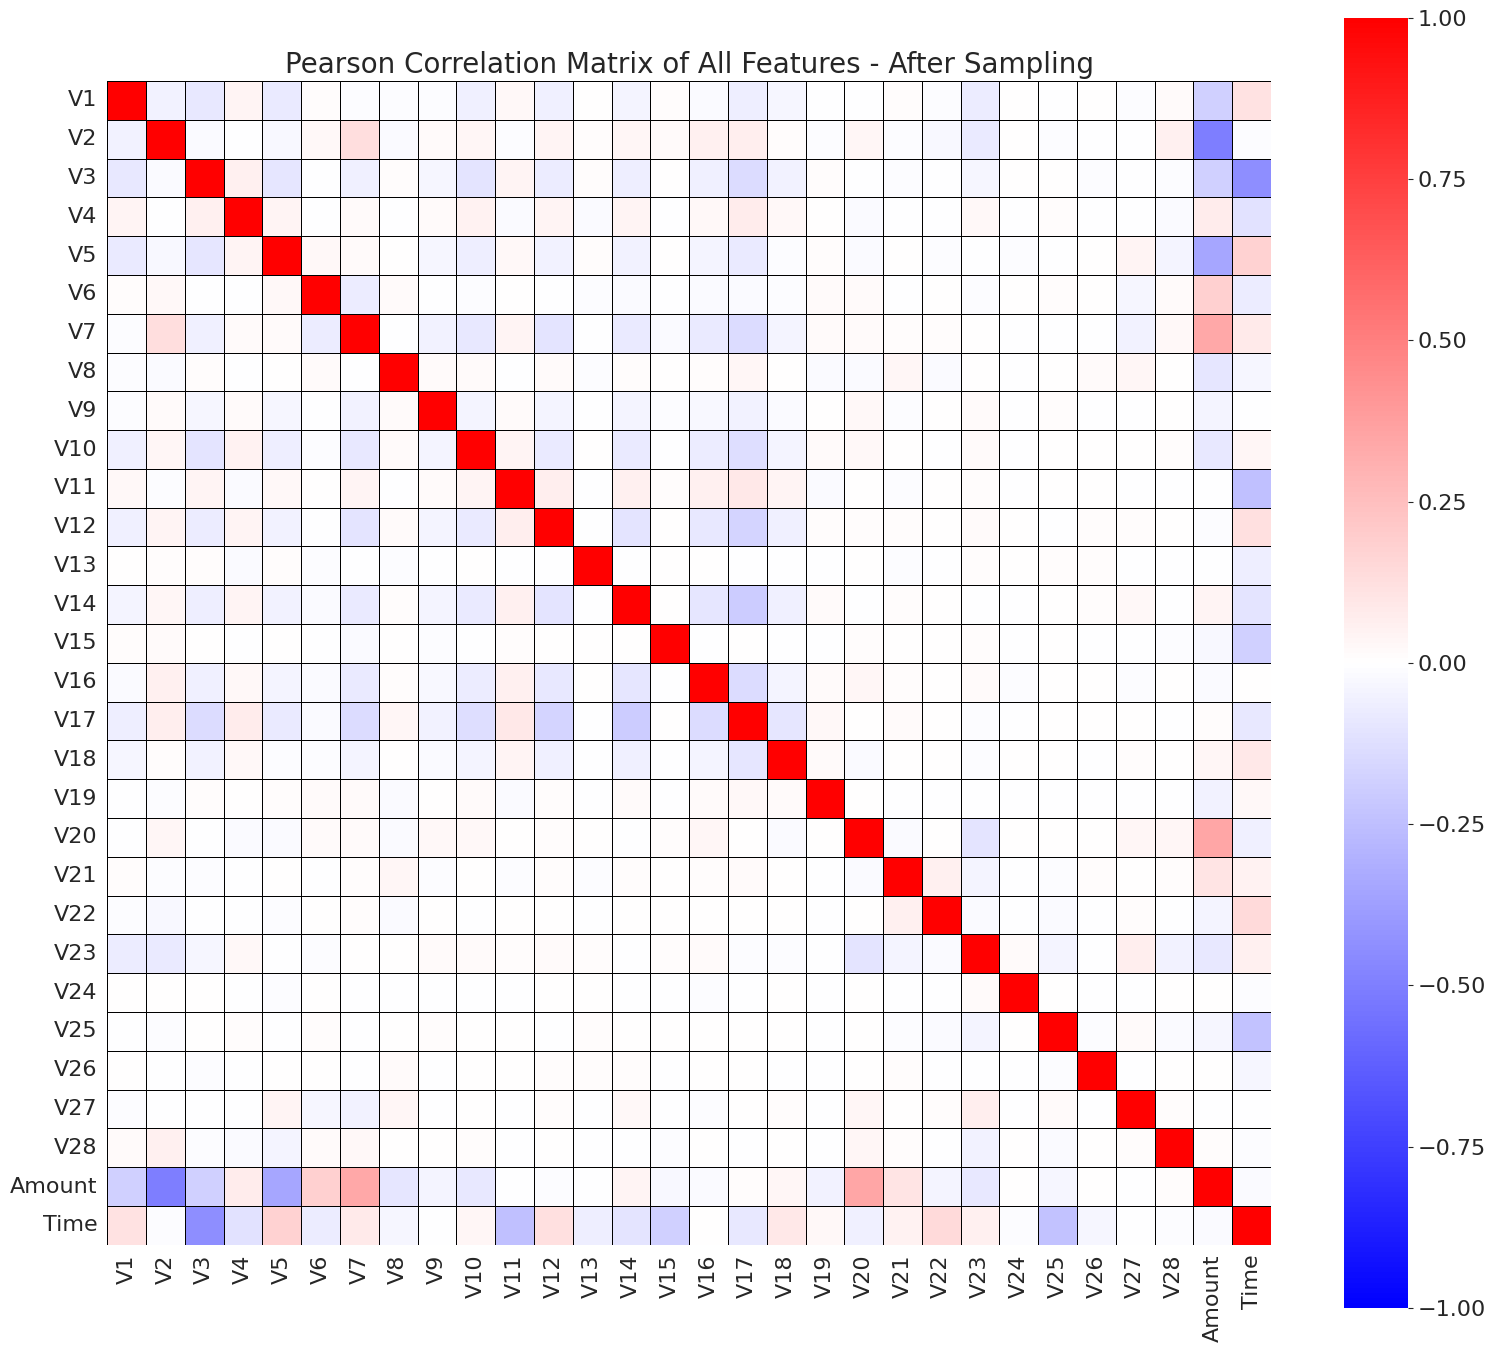

In [25]:
corr_after = df_compare.loc[df_compare["Sampled"] == "After", pcs_cols_name + ["Amount", "Time"]].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_after,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Pearson Correlation Matrix of All Features - After Sampling", fontsize=20)
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "all_features_correlation_matrix_after.png", dpi=300)
plt.show()

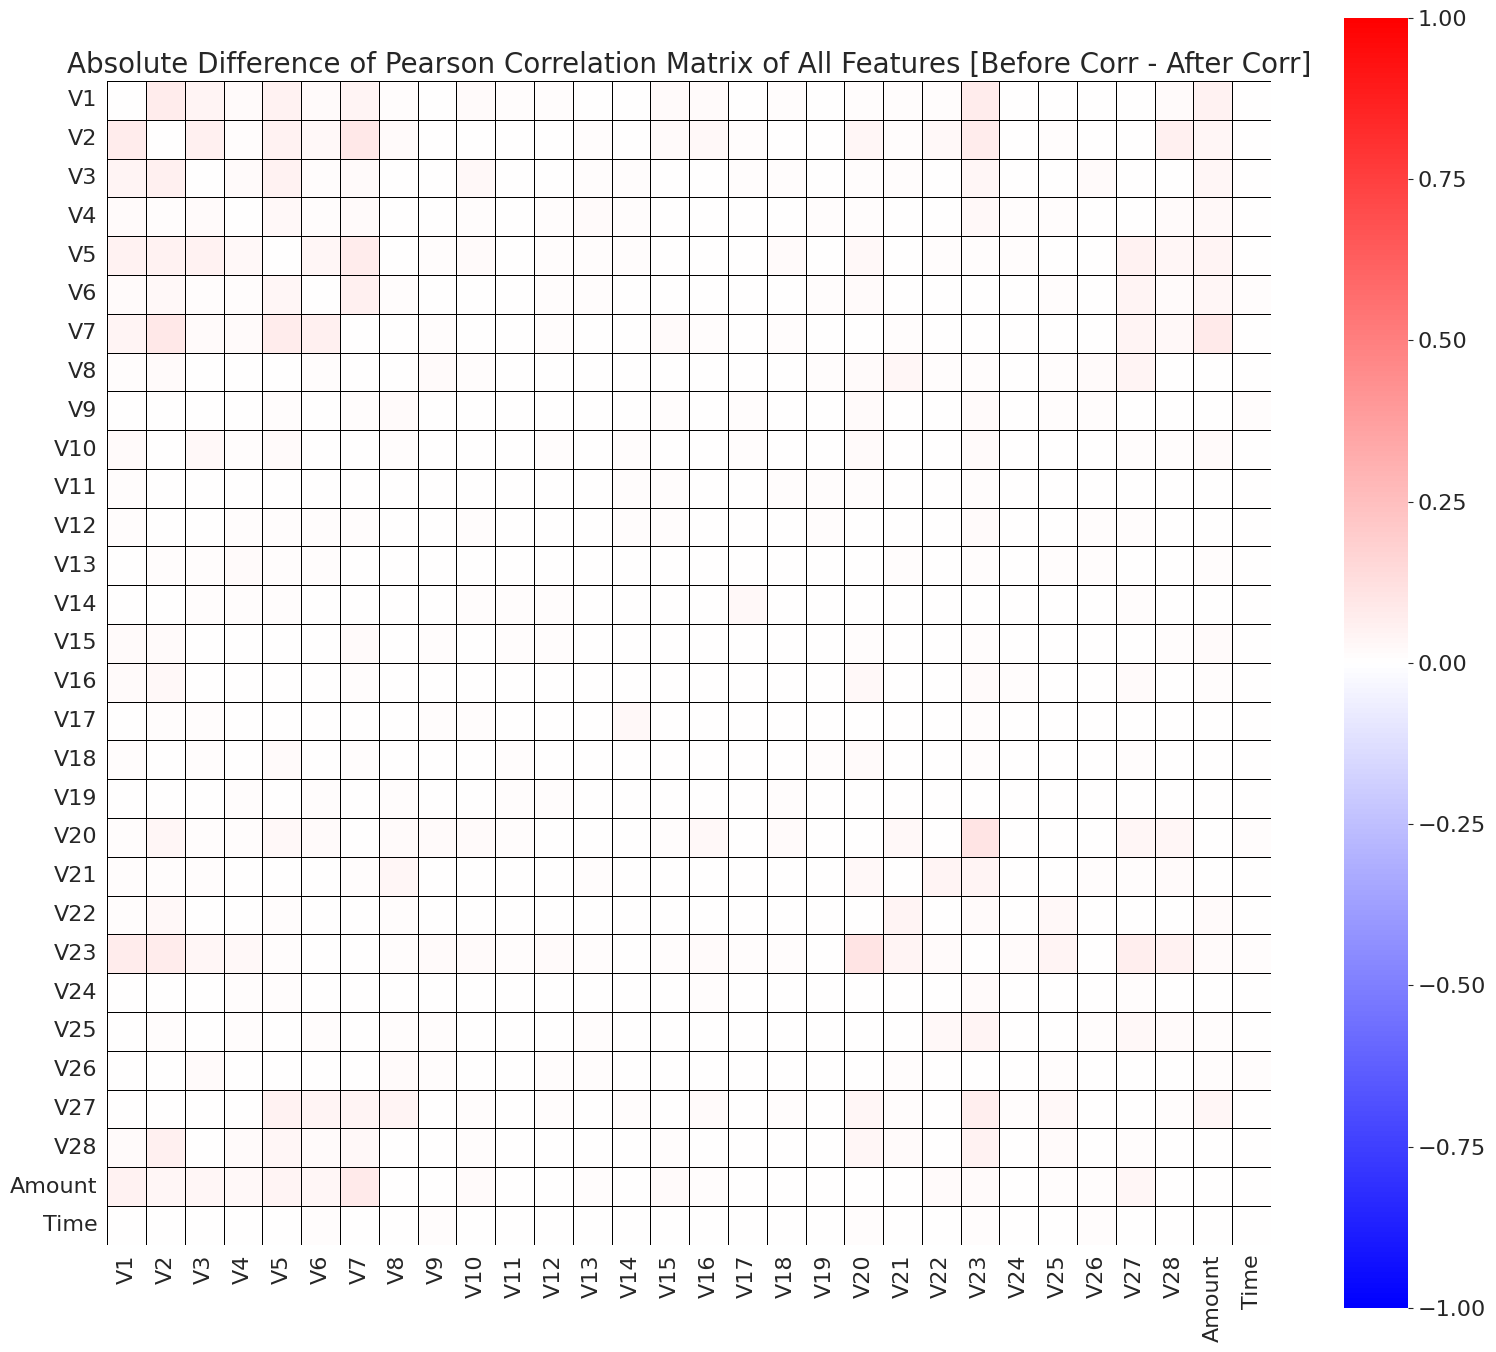

In [26]:
corr_diff = corr_before - corr_after
corr_diff_err = corr_diff.abs()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_diff_err,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Absolute Difference of Pearson Correlation Matrix of All Features [Before Corr - After Corr]", fontsize=20)
plt.tight_layout()
plt.savefig(FIGURES_SAMPLING_CHECKS_DIR / "all_features_correlation_matrix_abs_error_diff.png", dpi=300)
plt.show()